In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [2]:
adata_age_cd8= sc.read_h5ad("/scratch/user/s4575250/BIOX7014_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd8

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [4]:
adata_age_cd8.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      58370
4–6      64945
7–10     43721
11–14    72625
15–18    25907
Name: count, dtype: int64

In [5]:
adata_age_cd8.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1489
0.07      585
0.14      663
0.35     2293
0.48     1267
         ... 
16.16    1848
16.20    2413
16.29    2501
16.78    1559
17.03    3096
Name: count, Length: 122, dtype: int64

In [6]:
adata_age_cd8.obs["Sex"].value_counts().sort_index()

Sex
Female    113531
Male      152037
Name: count, dtype: int64

In [7]:
adata_age_cd8.obs["Age"].value_counts().sort_index()

Age
0     15038
1      9466
2     15862
3     18004
4     27429
5     14860
6     22656
7     16540
8     12849
9      7687
10     6645
11    20207
12    14386
13    14981
14    23051
15    12466
16    10345
17     3096
Name: count, dtype: int64

In [8]:
adata_age_cd8.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_cd8.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD8 naive/Tcm          175694
CD8 Tem                 50185
CD8 GZMK+ naive/Tcm     39689
Name: count, dtype: int64

In [9]:
adata_age_cd8.obs["Batch"] = adata_age_cd8.obs["Batch"].astype("category")
adata_age_cd8.obs["Age_years"] = adata_age_cd8.obs["Age_years"].astype("float")
adata_age_cd8.obs["Sex"] = adata_age_cd8.obs["Sex"].astype("category")
adata_age_cd8.obs["Age"] = adata_age_cd8.obs["Age"].astype("category")

In [10]:
adata_age_cd8.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1489
0.07      585
0.14      663
0.35     2293
0.48     1267
         ... 
16.16    1848
16.20    2413
16.29    2501
16.78    1559
17.03    3096
Name: count, Length: 122, dtype: int64

In [11]:
adata_age_cd8.obs["Batch"].value_counts().sort_index()

Batch
Batch01     3944
Batch02    46226
Batch03    50717
Batch04    54068
Batch05    31334
Batch06    48055
Batch07    31224
Name: count, dtype: int64

In [12]:
adata_age_cd8.obs.groupby("pica_id")["Age_years"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [1.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age_years, Length: 128, dtype: object

In [13]:
adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [14]:
adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [15]:
""" Age group
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="cell_type",   
    sample_col="pica_id",       
    covariates=("Age_group","Child's sex"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data
"""

' Age group\n# build sccoda input from cell-level data\ndef make_sccoda_from_lineage(\n    adata,\n    cell_type_col="cell_type",   \n    sample_col="pica_id",       \n    covariates=("Age_group","Child\'s sex"), \n):\n    sccoda_data = sccoda_model.load(\n        adata,\n        type="cell_level",\n        generate_sample_level=True,\n        cell_type_identifier=cell_type_col,\n        sample_identifier=sample_col,\n        covariate_obs=list(covariates),\n    )\n    return sccoda_data\n'

In [16]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="pica_cell_type_complete_01_gdT_corrected",   
    sample_col="pica_id",       
    covariates=("Age_years","Sex", "Batch", "Age"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [17]:
sccoda_cd8 = make_sccoda_from_lineage(adata_age_cd8, cell_type_col="pica_cell_type_complete_01_gdT_corrected")
sccoda_cd8

MuData object with n_obs × n_vars = 265696 × 38609
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	128 x 3
      obs:	'Age_years', 'Age', 'pica_id', 'Batch', 'Sex'
      var:	'n_cells'

### Run sccoda

In [18]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda", ref="automatic"):
    formula = "~ Age_years * Sex + Batch"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type=ref, 
    )
    return sccoda_data

In [19]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data


#### automatic ref cell type model (CD8 GZMK+ naive/Tcm)

In [21]:
cd8_auto = prepare_sccoda_age(sccoda_cd8.copy(), ref="automatic")

• Automatic reference selection! Reference cell type set to CD8 GZMK+ naive/Tcm
• Zero counts encountered in data! Added a pseudocount of 0.5.


In [22]:
cd8_auto = run_sccoda(cd8_auto, rng_key=1)

sample: 100%|██████████| 7000/7000 [04:06<00:00, 28.41it/s, 511 steps of size 8.40e-03. acc. prob=0.76] 


In [23]:
sccoda_model.summary(cd8_auto, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 3 cell types                                         │
│ Reference cell type                   │ CD8 GZMK+ naive/Tcm                                                     │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 76.1%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD8 GZMK+ naive/Tcm                           0.597        0.431   0.768   0.091      374.447                   │
│ CD8 Tem                                       0.271        0.041   0.519   0.129      270.278                   │
│ CD8 naive/Tcm                                 1.937        1.724   2.164   0.122     1430.029                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                          Final Parameter  Expected Sample  log2-fold change                     │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
│ BatchT.Batch02      CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
│ BatchT.Batch03      CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
│ BatchT.Batch04      CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
│ BatchT.Batch05      CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
│ BatchT.Batch06      CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
│ BatchT.Batch07      CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
│ Age_years           CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
│ Age_years:SexT.Male CD8 GZMK+ naive/Tcm      0.000            374.447           0.000                           │
│                     CD8 Tem                  0.000            270.278           0.000                           │
│                     CD8 naive/Tcm            0.000           1430.029           0.000                           │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                          HDI 3%  HDI 97%   SD   Inclusion probability                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.277  0.363   0.095         0.338                                    │
│                     CD8 naive/Tcm        -0.122  0.311   0.082         0.356                                    │
│ BatchT.Batch02      CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.188  0.341   0.097         0.377                                    │
│                     CD8 naive/Tcm        -0.308  0.154   0.078         0.323                                    │
│ BatchT.Batch03      CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.142  0.415   0.103         0.367                                    │
│                     CD8 naive/Tcm        -0.353  0.125   0.090         0.359                                    │
│ BatchT.Batch04      CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.408  0.144   0.103         0.343                                    │
│                     CD8 naive/Tcm        -0.106  0.400   0.115         0.429                                    │
│ BatchT.Batch05      CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.136  0.644   0.199         0.552                                    │
│                     CD8 naive/Tcm        -0.640  0.020   0.213         0.682                                    │
│ BatchT.Batch06      CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.293  0.274   0.081         0.319                                    │
│                     CD8 naive/Tcm        -0.194  0.224   0.066         0.325                                    │
│ BatchT.Batch07      CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.286  0.251   0.080         0.316                                    │
│                     CD8 naive/Tcm        -0.305  0.207   0.080         0.336                                    │
│ Age_years           CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.026  0.022   0.006         0.150                                    │
│                     CD8 naive/Tcm        -0.022  0.016   0.004         0.095                                    │
│ Age_years:SexT.Male CD8 GZMK+ naive/Tcm   0.000  0.000   0.000         0.000                                    │
│                     CD8 Tem              -0.000  0.059   0.016         0.928                                    │
│                     CD8 naive/Tcm        -0.037  0.014   0.006         0.140                                    │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [24]:
# set desired FDR globally
sccoda_model.set_fdr(cd8_auto, est_fdr=0.1, modality_key="coda")

In [25]:
# check threshold
cd8_auto["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.927)

In [26]:
effects_cd8_auto = sccoda_model.get_effect_df(cd8_auto, modality_key="coda")

effects_cd8_auto["Inclusion probability"].max()
effects_cd8_auto["Inclusion probability"].describe()

count    27.000000
mean      0.249444
std       0.238138
min       0.000000
25%       0.000000
50%       0.319000
75%       0.357500
max       0.927800
Name: Inclusion probability, dtype: float64

In [27]:
# effects dataframe
effects_cd8_auto = sccoda_model.get_effect_df(cd8_auto, modality_key="coda")
effects_cd8_auto.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate      Cell Type                                                      
SexT.Male      CD8 GZMK+ naive/Tcm              0.0   0.000    0.000  0.000   
               CD8 Tem                          0.0  -0.277    0.363  0.095   
               CD8 naive/Tcm                    0.0  -0.122    0.311  0.082   
BatchT.Batch02 CD8 GZMK+ naive/Tcm              0.0   0.000    0.000  0.000   
               CD8 Tem                          0.0  -0.188    0.341  0.097   

                                    Inclusion probability  Expected Sample  \
Covariate      Cell Type                                                     
SexT.Male      CD8 GZMK+ naive/Tcm                 0.0000       374.446952   
               CD8 Tem                             0.3378       270.277753   
               CD8 naive/Tcm                       0.3556      1430.029201   
BatchT.Batch02 CD8 GZMK+ naive/Tcm                 0.0000       374.446952   
               CD8 Tem                             0.3768       270.277753   

                                    log2-fold change  
Covariate      Cell Type                              
SexT.Male      CD8 GZMK+ naive/Tcm               0.0  
               CD8 Tem                           0.0  
               CD8 naive/Tcm                     0.0  
BatchT.Batch02 CD8 GZMK+ naive/Tcm               0.0  
               CD8 Tem                           0.0

In [28]:
# counts per sample x celltype
counts = pd.DataFrame(
    cd8_auto["coda"].X,
    index=cd8_auto["coda"].obs_names,
    columns=cd8_auto["coda"].var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = cd8_auto["coda"].obs.copy()

# long format for plotting
df = (
    props.join(meta[["Age_years", "Age", "Sex"]])
    .reset_index(names="sample")
    .melt(
        id_vars=["sample", "Age_years", "Age", "Sex"],
        var_name="pica_cell_type_complete_01_gdT_corrected",
        value_name="Proportion"
    )
)

In [29]:
df["pica_cell_type_complete_01_gdT_corrected"].unique()

array(['CD8 GZMK+ naive/Tcm', 'CD8 Tem', 'CD8 naive/Tcm'], dtype=object)

In [30]:
df["Age"].unique()

[2, 15, 0, 1, 9, ..., 12, 11, 14, 8, 17]
Length: 18
Categories (18, int64): [0, 1, 2, 3, ..., 14, 15, 16, 17]

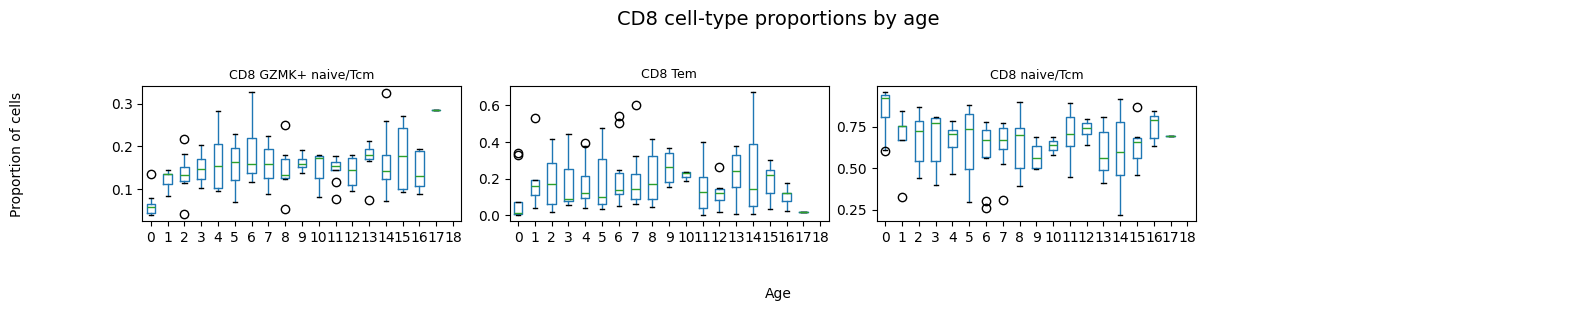

In [31]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["pica_cell_type_complete_01_gdT_corrected"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["pica_cell_type_complete_01_gdT_corrected"] == cell]
    sub.boxplot(
        column="Proportion",
        by="Age",
        grid=False,
        ax=ax
    )

    ax.set_xticks(range(1, 20))
    ax.set_xticklabels(range(0, 19))
    ax.set_xlim(0.5, 19.5)
    
    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("CD8 cell-type proportions by age", fontsize=14)
fig.supxlabel("Age", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

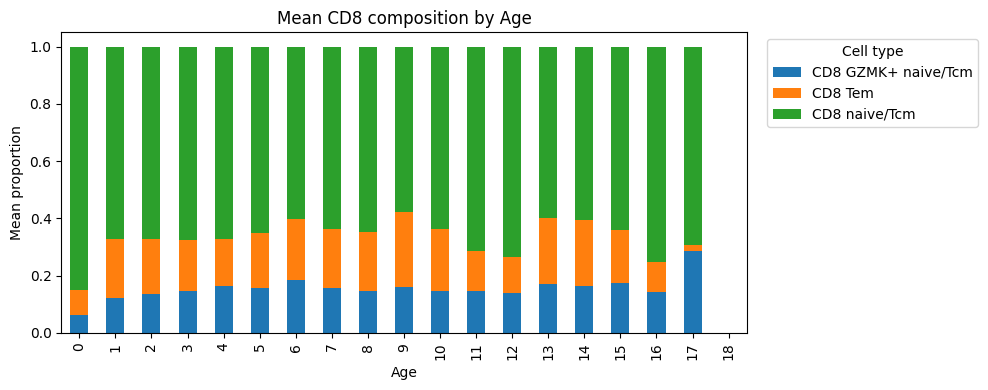

In [32]:
# barplot of composition by age group
props_age = props.join(meta["Age"]).groupby("Age").mean().reindex(range(0, 19))

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean CD8 composition by Age")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

In [33]:
# Filter out Batch before plotting
effects_cd8_auto_plot = effects_cd8_auto[
    ~effects_cd8_auto.index.get_level_values("Covariate").str.startswith("Batch")
]

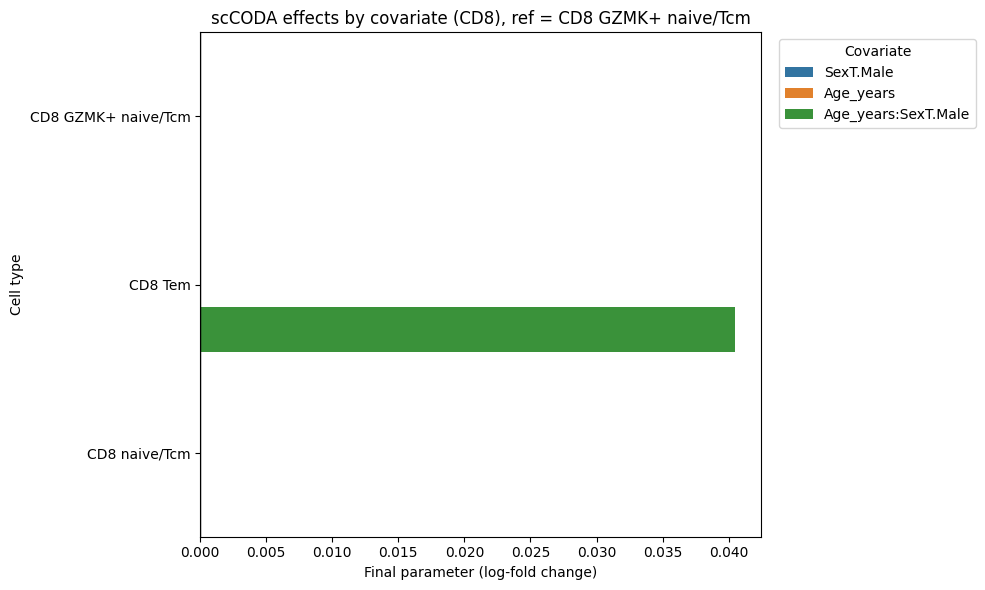

In [34]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd8_auto_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD8), ref = CD8 GZMK+ naive/Tcm")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

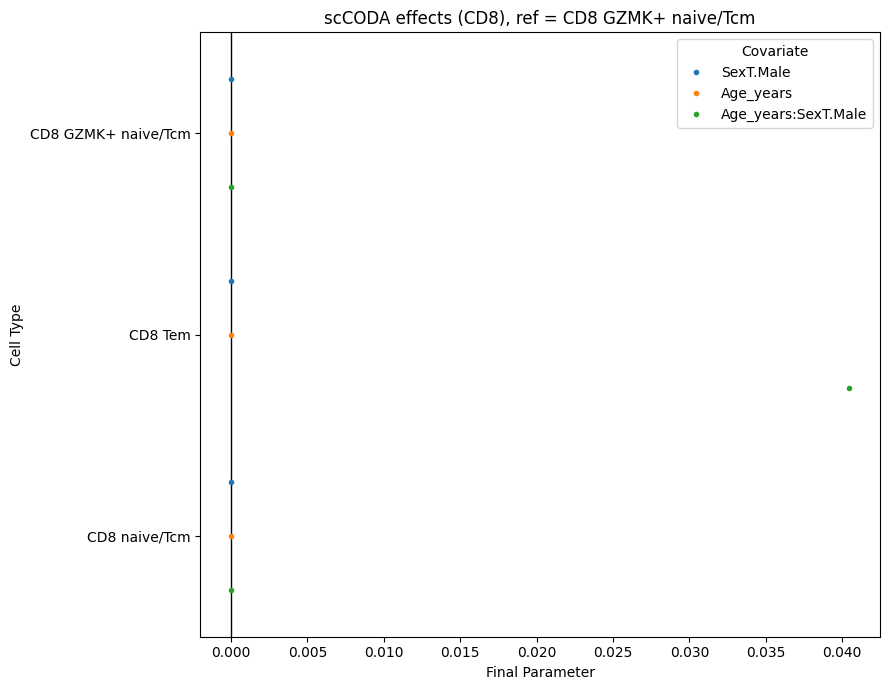

In [35]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd8_auto_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD8), ref = CD8 GZMK+ naive/Tcm")
plt.tight_layout()
plt.show()

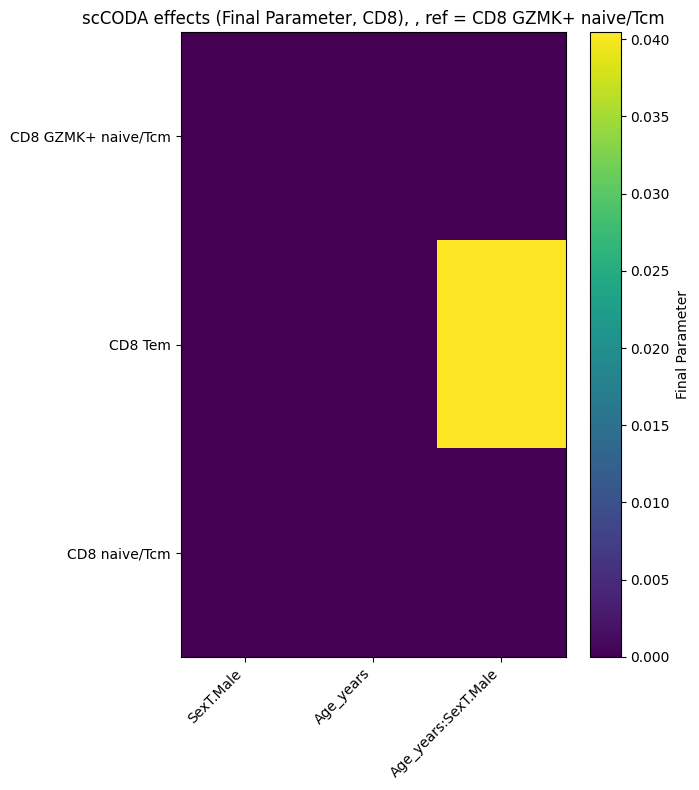

In [36]:
# inclusion pronbability heatmap
tmp_auto = effects_cd8_auto_plot.reset_index()
ip_auto = tmp_auto.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_auto = effects_cd8_auto_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_auto.values, aspect="auto")
plt.yticks(range(beta_auto.shape[0]), beta_auto.index)
plt.xticks(range(beta_auto.shape[1]), beta_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD8), , ref = CD8 GZMK+ naive/Tcm")
plt.tight_layout()
plt.show()

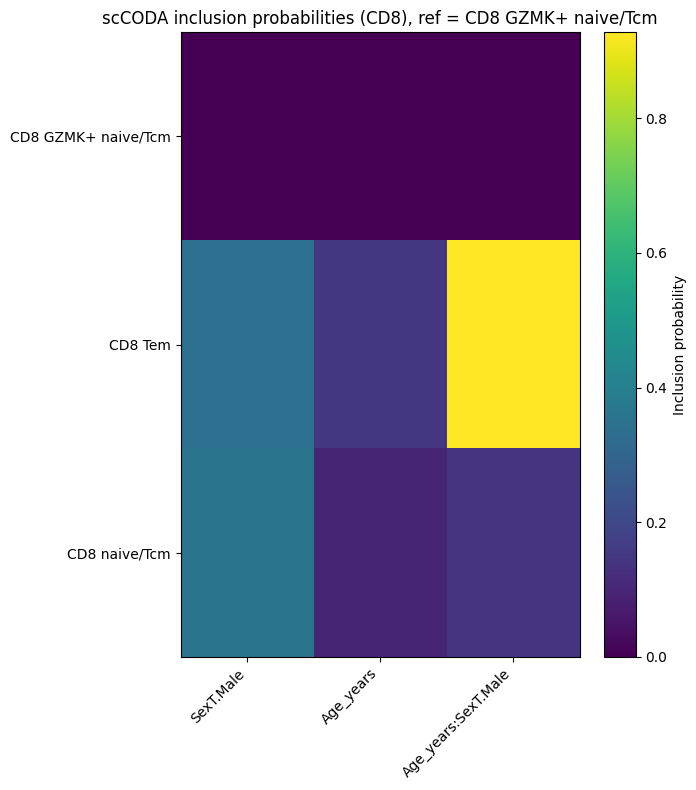

In [37]:
ip_auto = effects_cd8_auto_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_auto.values, aspect="auto")
plt.yticks(range(ip_auto.shape[0]), ip_auto.index)
plt.xticks(range(ip_auto.shape[1]), ip_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD8), ref = CD8 GZMK+ naive/Tcm")
plt.tight_layout()
plt.show()

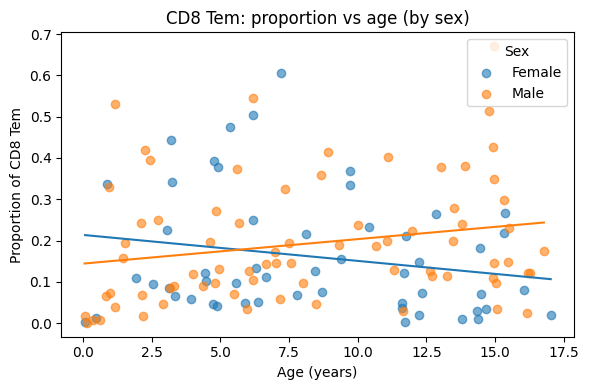

In [38]:
cell = "CD8 Tem"
d = df[df["pica_cell_type_complete_01_gdT_corrected"] == cell].copy()

fig, ax = plt.subplots(figsize=(6,4))

for sex, sub in d.groupby("Sex"):
    x = sub["Age_years"].to_numpy()
    y = sub["Proportion"].to_numpy()

    ax.scatter(x, y, alpha=0.6, label=sex)

    # simple linear fit (visualisation)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, m*xs + b)

ax.set_xlabel("Age (years)")
ax.set_ylabel(f"Proportion of {cell}")
ax.set_title(f"{cell}: proportion vs age (by sex)")
ax.legend(title="Sex")
plt.tight_layout()
plt.show()

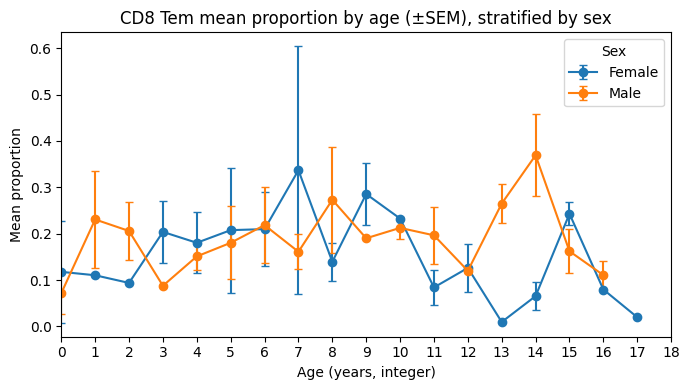

In [39]:
d = df[df["pica_cell_type_complete_01_gdT_corrected"] == "CD8 Tem"].copy()

# ensure integer ages exist up to 18
d["Age"] = d["Age"].astype(int)

fig, ax = plt.subplots(figsize=(7,4))

for sex, sub in d.groupby("Sex"):
    g = sub.groupby("Age")["Proportion"]
    mean = g.mean().reindex(range(0, 19))
    sem  = g.sem().reindex(range(0, 19))

    ax.errorbar(mean.index, mean.values, yerr=sem.values, fmt="o-", capsize=3, label=sex)

ax.set_xlabel("Age (years, integer)")
ax.set_ylabel("Mean proportion")
ax.set_title("CD8 Tem mean proportion by age (±SEM), stratified by sex")
ax.set_xlim(0, 18)
ax.set_xticks(range(0, 19))
ax.legend(title="Sex")
plt.tight_layout()
plt.show()

#### ref cell type model (CD8 naive/Tcm)

In [20]:
cd8_naive = prepare_sccoda_age(sccoda_cd8.copy(), ref="CD8 naive/Tcm")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [21]:
cd8_naive = run_sccoda(cd8_naive, rng_key=1)

sample: 100%|██████████| 7000/7000 [04:14<00:00, 27.46it/s, 511 steps of size 7.98e-03. acc. prob=0.69] 


In [22]:
sccoda_model.summary(cd8_naive, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 3 cell types                                         │
│ Reference cell type                   │ CD8 naive/Tcm                                                           │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 2                                                                       │
│ Spike-and-slab threshold              │ 0.971                                                                   │
│ Spike-and-slab threshold              │ 0.971                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 68.5%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD8 GZMK+ naive/Tcm                           0.510        0.248   0.783   0.146      352.151                   │
│ CD8 Tem                                       0.250        0.001   0.505   0.136      271.527                   │
│ CD8 naive/Tcm                                 1.926        1.742   2.097   0.096     1451.076                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                          Final Parameter  Expected Sample  log2-fold change                     │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD8 GZMK+ naive/Tcm      0.000            352.151            0.000                          │
│                     CD8 Tem                  0.000            271.527            0.000                          │
│                     CD8 naive/Tcm            0.000           1451.076            0.000                          │
│ BatchT.Batch02      CD8 GZMK+ naive/Tcm      0.000            352.151            0.000                          │
│                     CD8 Tem                  0.000            271.527            0.000                          │
│                     CD8 naive/Tcm            0.000           1451.076            0.000                          │
│ BatchT.Batch03      CD8 GZMK+ naive/Tcm      0.000            352.151            0.000                          │
│                     CD8 Tem                  0.000            271.527            0.000                          │
│                     CD8 naive/Tcm            0.000           1451.076            0.000                          │
│ BatchT.Batch04      CD8 GZMK+ naive/Tcm      0.000            352.151            0.000                          │
│                     CD8 Tem                  0.000            271.527            0.000                          │
│                     CD8 naive/Tcm            0.000           1451.076            0.000                          │
│ BatchT.Batch05      CD8 GZMK+ naive/Tcm      0.000            352.151            0.000                          │
│                     CD8 Tem                  0.000            271.527            0.000                          │
│                     CD8 naive/Tcm            0.000           1451.076            0.000                          │
│ BatchT.Batch06      CD8 GZMK+ naive/Tcm      0.000            352.151            0.000                          │
│                     CD8 Tem                  0.000            271.527            0.000                          │
│                     CD8 naive/Tcm            0.000           1451.076            0.000                          │
│ BatchT.Batch07      CD8 GZMK+ naive/Tcm      0.000            352.151            0.000                          │
│                     CD8 Tem                  0.000            271.527            0.000                          │
│                     CD8 naive/Tcm            0.000           1451.076            0.000                          │
│ Age_years           CD8 GZMK+ naive/Tcm      0.000            352.151            0.000                          │
│                     CD8 Tem                  0.000            271.527            0.000                          │
│                     CD8 naive/Tcm            0.000           1451.076            0.000                          │
│ Age_years:SexT.Male CD8 GZMK+ naive/Tcm      0.000            350.170           -0.008                          │
│                     CD8 Tem                  0.042            281.670            0.053                          │
│                     CD8 naive/Tcm            0.000           1442.914           -0.008                          │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                          HDI 3%  HDI 97%   SD   Inclusion probability                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD8 GZMK+ naive/Tcm  -0.353  0.167   0.087         0.339                                    │
│                     CD8 Tem              -0.381  0.322   0.103         0.347                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
│ BatchT.Batch02      CD8 GZMK+ naive/Tcm  -0.214  0.244   0.063         0.299                                    │
│                     CD8 Tem              -0.139  0.406   0.096         0.354                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
│ BatchT.Batch03      CD8 GZMK+ naive/Tcm  -0.209  0.256   0.065         0.295                                    │
│                     CD8 Tem              -0.143  0.403   0.116         0.425                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
│ BatchT.Batch04      CD8 GZMK+ naive/Tcm  -0.207  0.299   0.080         0.357                                    │
│                     CD8 Tem              -0.444  0.129   0.116         0.415                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
│ BatchT.Batch05      CD8 GZMK+ naive/Tcm  -0.147  0.463   0.119         0.370                                    │
│                     CD8 Tem              -0.041  0.677   0.229         0.733                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
│ BatchT.Batch06      CD8 GZMK+ naive/Tcm  -0.336  0.161   0.083         0.311                                    │
│                     CD8 Tem              -0.311  0.206   0.074         0.315                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
│ BatchT.Batch07      CD8 GZMK+ naive/Tcm  -0.274  0.291   0.084         0.322                                    │
│                     CD8 Tem              -0.325  0.238   0.079         0.300                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
│ Age_years           CD8 GZMK+ naive/Tcm  -0.001  0.043   0.014         0.437                                    │
│                     CD8 Tem              -0.033  0.017   0.006         0.136                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
│ Age_years:SexT.Male CD8 GZMK+ naive/Tcm  -0.012  0.039   0.009         0.204                                    │
│                     CD8 Tem              -0.000  0.061   0.014         0.971                                    │
│                     CD8 naive/Tcm         0.000  0.000   0.000         0.000                                    │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [23]:
# set desired FDR globally
sccoda_model.set_fdr(cd8_naive, est_fdr=0.1, modality_key="coda")

In [24]:
# check threshold
cd8_naive["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.971)

In [25]:
effects_cd8_naive = sccoda_model.get_effect_df(cd8_naive, modality_key="coda")

effects_cd8_naive["Inclusion probability"].max()
effects_cd8_naive["Inclusion probability"].describe()

count    27.000000
mean      0.256704
std       0.239935
min       0.000000
25%       0.000000
50%       0.299800
75%       0.355600
max       0.971200
Name: Inclusion probability, dtype: float64

In [26]:
# effects dataframe
effects_cd8_naive = sccoda_model.get_effect_df(cd8_naive, modality_key="coda")
effects_cd8_naive.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate      Cell Type                                                      
SexT.Male      CD8 GZMK+ naive/Tcm              0.0  -0.353    0.167  0.087   
               CD8 Tem                          0.0  -0.381    0.322  0.103   
               CD8 naive/Tcm                    0.0   0.000    0.000  0.000   
BatchT.Batch02 CD8 GZMK+ naive/Tcm              0.0  -0.214    0.244  0.063   
               CD8 Tem                          0.0  -0.139    0.406  0.096   

                                    Inclusion probability  Expected Sample  \
Covariate      Cell Type                                                     
SexT.Male      CD8 GZMK+ naive/Tcm                 0.3392       352.151194   
               CD8 Tem                             0.3474       271.526737   
               CD8 naive/Tcm                       0.0000      1451.075975   
BatchT.Batch02 CD8 GZMK+ naive/Tcm                 0.2994       352.151194   
               CD8 Tem                             0.3538       271.526737   

                                    log2-fold change  
Covariate      Cell Type                              
SexT.Male      CD8 GZMK+ naive/Tcm               0.0  
               CD8 Tem                           0.0  
               CD8 naive/Tcm                     0.0  
BatchT.Batch02 CD8 GZMK+ naive/Tcm               0.0  
               CD8 Tem                           0.0

In [27]:
# Filter out Batch before plotting
effects_cd8_naive_plot = effects_cd8_naive[
    ~effects_cd8_naive.index.get_level_values("Covariate").str.startswith("Batch")
]

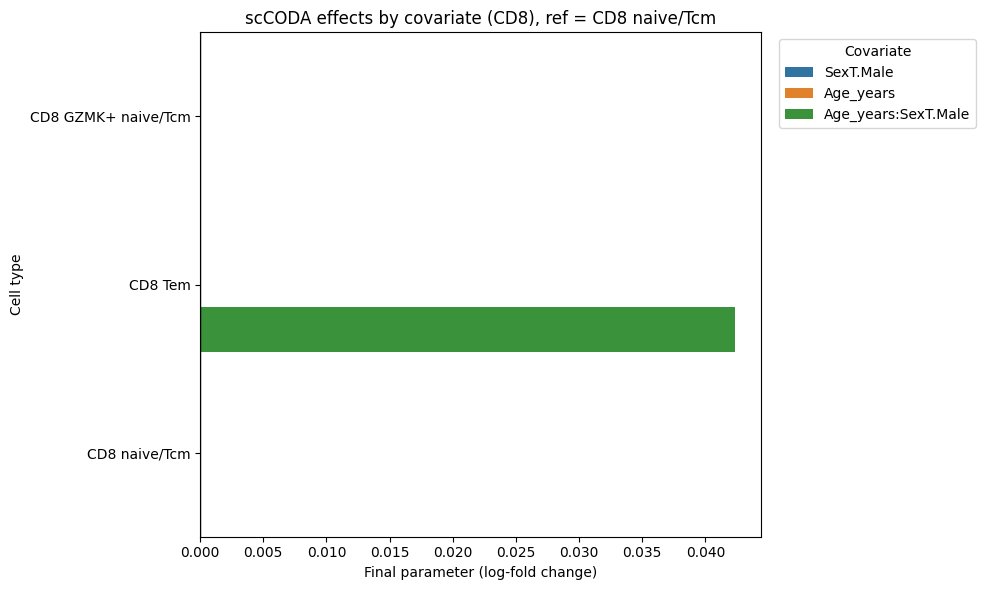

In [28]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd8_naive_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD8), ref = CD8 naive/Tcm")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

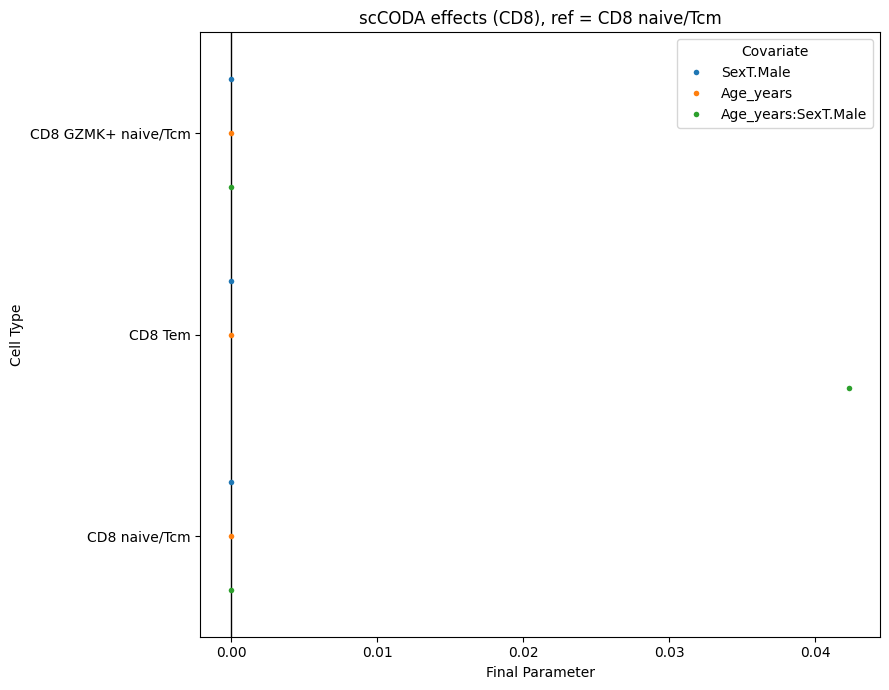

In [29]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd8_naive_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD8), ref = CD8 naive/Tcm")
plt.tight_layout()
plt.show()

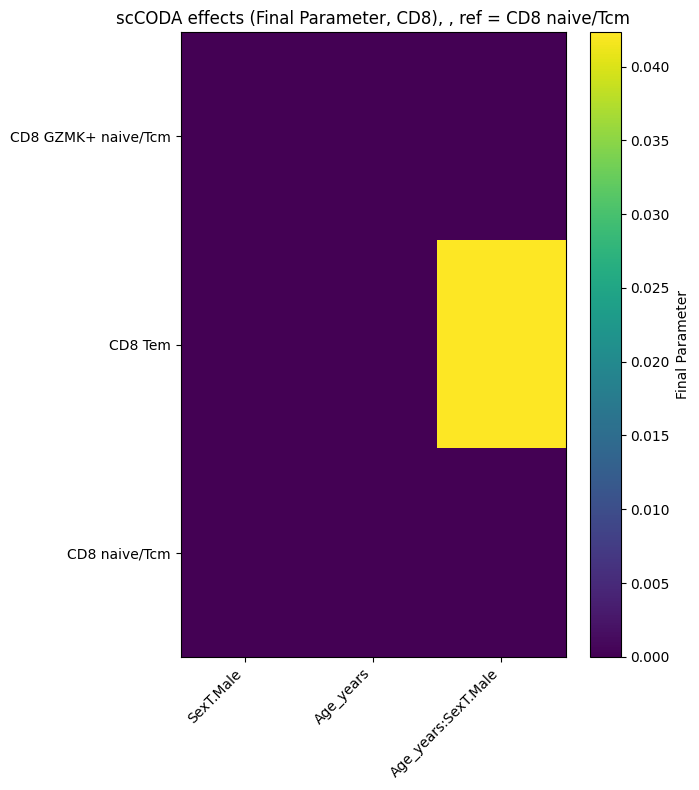

In [30]:
# inclusion pronbability heatmap
tmp_naive = effects_cd8_naive_plot.reset_index()
ip_naive = tmp_naive.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_naive = effects_cd8_naive_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_naive.values, aspect="auto")
plt.yticks(range(beta_naive.shape[0]), beta_naive.index)
plt.xticks(range(beta_naive.shape[1]), beta_naive.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD8), , ref = CD8 naive/Tcm")
plt.tight_layout()
plt.show()

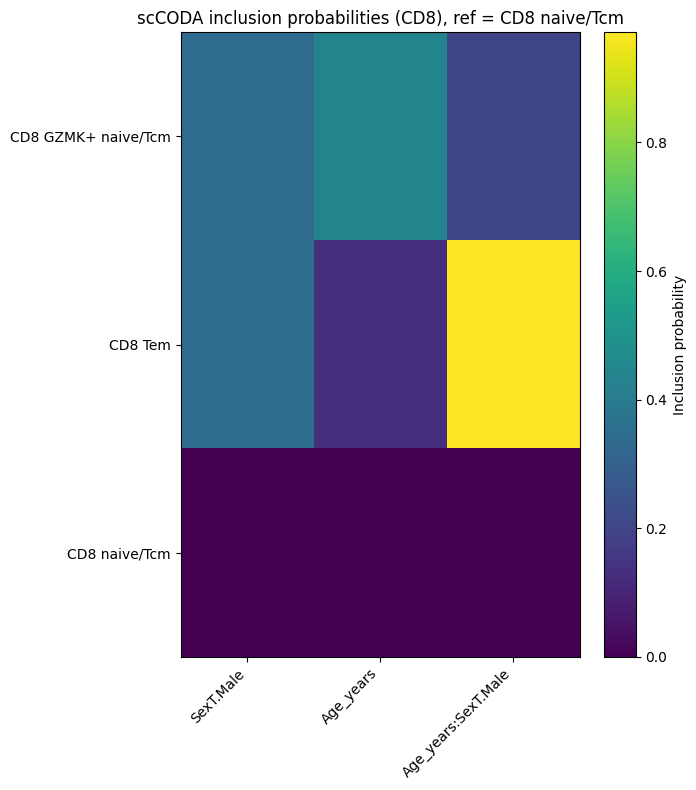

In [31]:
ip_naive = effects_cd8_naive_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_naive.values, aspect="auto")
plt.yticks(range(ip_naive.shape[0]), ip_naive.index)
plt.xticks(range(ip_naive.shape[1]), ip_naive.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD8), ref = CD8 naive/Tcm")
plt.tight_layout()
plt.show()

#### ref cell type model (CD8 Tem)

In [20]:
cd8_tem = prepare_sccoda_age(sccoda_cd8.copy(), ref="CD8 Tem")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [21]:
cd8_tem = run_sccoda(cd8_tem, rng_key=1)

sample: 100%|██████████| 7000/7000 [04:21<00:00, 26.74it/s, 511 steps of size 6.95e-03. acc. prob=0.89] 


In [22]:
sccoda_model.summary(cd8_tem, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 3 cell types                                         │
│ Reference cell type                   │ CD8 Tem                                                                 │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 1                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 88.7%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD8 GZMK+ naive/Tcm                           0.529        0.262   0.790   0.142      347.504                   │
│ CD8 Tem                                       0.436        0.262   0.619   0.095      316.643                   │
│ CD8 naive/Tcm                                 1.930        1.683   2.219   0.141     1410.607                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                          Final Parameter  Expected Sample  log2-fold change                     │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
│ BatchT.Batch02      CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
│ BatchT.Batch03      CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
│ BatchT.Batch04      CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
│ BatchT.Batch05      CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
│ BatchT.Batch06      CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
│ BatchT.Batch07      CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
│ Age_years           CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
│ Age_years:SexT.Male CD8 GZMK+ naive/Tcm      0.000            347.504           0.000                           │
│                     CD8 Tem                  0.000            316.643           0.000                           │
│                     CD8 naive/Tcm            0.000           1410.607           0.000                           │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                          HDI 3%  HDI 97%   SD   Inclusion probability                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD8 GZMK+ naive/Tcm  -0.341  0.124   0.092         0.361                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.216  0.366   0.094         0.344                                    │
│ BatchT.Batch02      CD8 GZMK+ naive/Tcm  -0.269  0.236   0.074         0.305                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.393  0.134   0.093         0.343                                    │
│ BatchT.Batch03      CD8 GZMK+ naive/Tcm  -0.182  0.285   0.071         0.322                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.337  0.142   0.088         0.364                                    │
│ BatchT.Batch04      CD8 GZMK+ naive/Tcm  -0.089  0.643   0.206         0.549                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.047  0.661   0.217         0.619                                    │
│ BatchT.Batch05      CD8 GZMK+ naive/Tcm  -0.406  0.310   0.111         0.339                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.737  0.014   0.240         0.780                                    │
│ BatchT.Batch06      CD8 GZMK+ naive/Tcm  -0.361  0.141   0.083         0.322                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.247  0.243   0.072         0.312                                    │
│ BatchT.Batch07      CD8 GZMK+ naive/Tcm  -0.225  0.352   0.094         0.353                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.298  0.236   0.080         0.330                                    │
│ Age_years           CD8 GZMK+ naive/Tcm  -0.002  0.040   0.009         0.230                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.034  0.015   0.006         0.136                                    │
│ Age_years:SexT.Male CD8 GZMK+ naive/Tcm  -0.026  0.023   0.005         0.123                                    │
│                     CD8 Tem               0.000  0.000   0.000         0.000                                    │
│                     CD8 naive/Tcm        -0.048  0.003   0.014         0.304                                    │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [23]:
# set desired FDR globally
sccoda_model.set_fdr(cd8_tem, est_fdr=0.1, modality_key="coda")

In [24]:
# check threshold
cd8_tem["coda"].uns["scCODA_params"]["threshold_prob"]

1.0

In [25]:
effects_cd8_tem = sccoda_model.get_effect_df(cd8_tem, modality_key="coda")

effects_cd8_tem["Inclusion probability"].max()
effects_cd8_tem["Inclusion probability"].describe()

count    27.000000
mean      0.238326
std       0.213288
min       0.000000
25%       0.000000
50%       0.305000
75%       0.343700
max       0.780200
Name: Inclusion probability, dtype: float64

In [26]:
# effects dataframe
effects_cd8_tem = sccoda_model.get_effect_df(cd8_tem, modality_key="coda")
effects_cd8_tem.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate      Cell Type                                                      
SexT.Male      CD8 GZMK+ naive/Tcm              0.0  -0.341    0.124  0.092   
               CD8 Tem                          0.0   0.000    0.000  0.000   
               CD8 naive/Tcm                    0.0  -0.216    0.366  0.094   
BatchT.Batch02 CD8 GZMK+ naive/Tcm              0.0  -0.269    0.236  0.074   
               CD8 Tem                          0.0   0.000    0.000  0.000   

                                    Inclusion probability  Expected Sample  \
Covariate      Cell Type                                                     
SexT.Male      CD8 GZMK+ naive/Tcm                 0.3610       347.503733   
               CD8 Tem                             0.0000       316.643143   
               CD8 naive/Tcm                       0.3444      1410.607030   
BatchT.Batch02 CD8 GZMK+ naive/Tcm                 0.3050       347.503733   
               CD8 Tem                             0.0000       316.643143   

                                    log2-fold change  
Covariate      Cell Type                              
SexT.Male      CD8 GZMK+ naive/Tcm               0.0  
               CD8 Tem                           0.0  
               CD8 naive/Tcm                     0.0  
BatchT.Batch02 CD8 GZMK+ naive/Tcm               0.0  
               CD8 Tem                           0.0

In [27]:
# Filter out Batch before plotting
effects_cd8_tem_plot = effects_cd8_tem[
    ~effects_cd8_tem.index.get_level_values("Covariate").str.startswith("Batch")
]

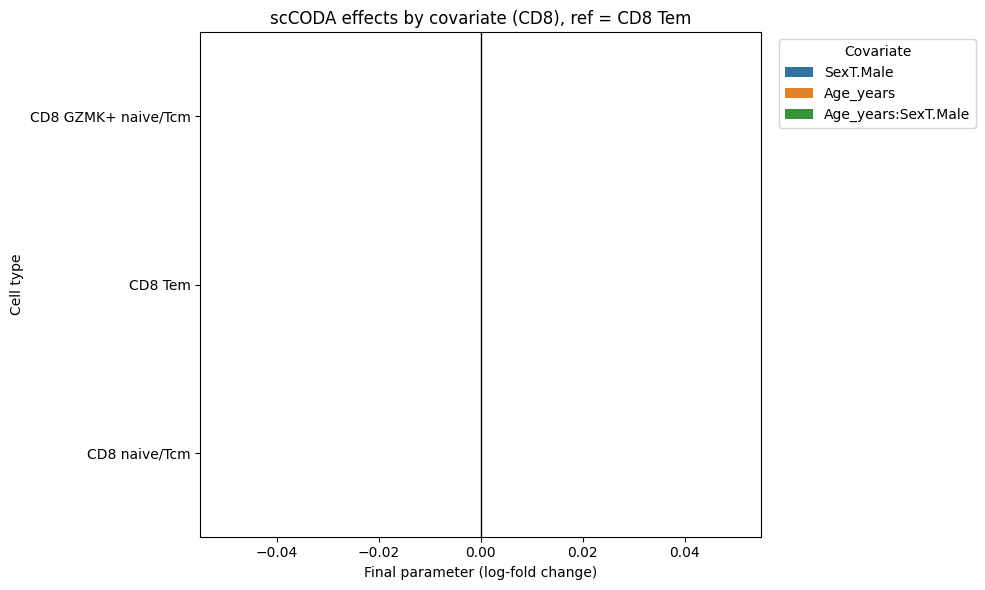

In [28]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd8_tem_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD8), ref = CD8 Tem")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

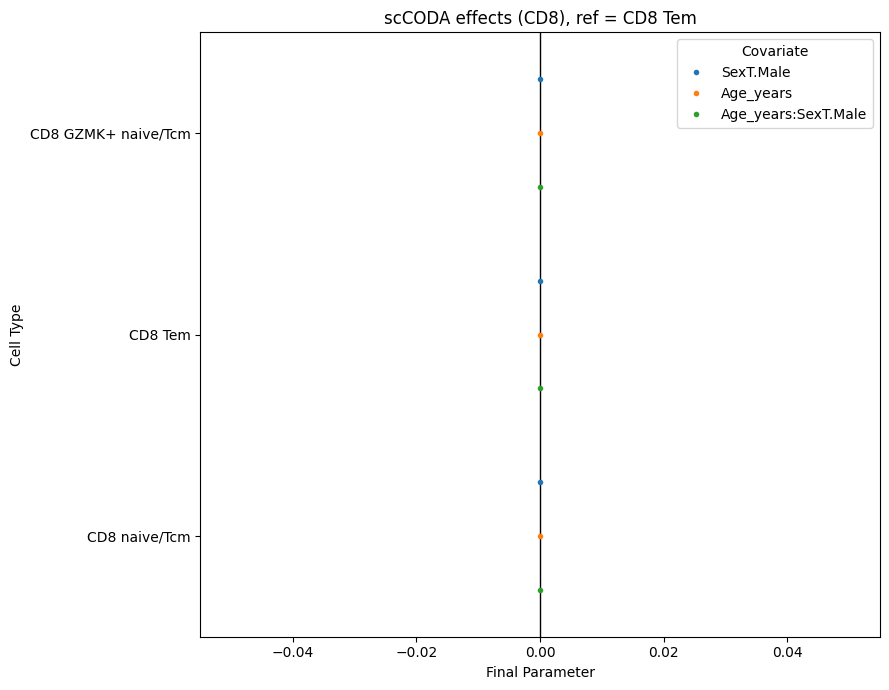

In [29]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd8_tem_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD8), ref = CD8 Tem")
plt.tight_layout()
plt.show()

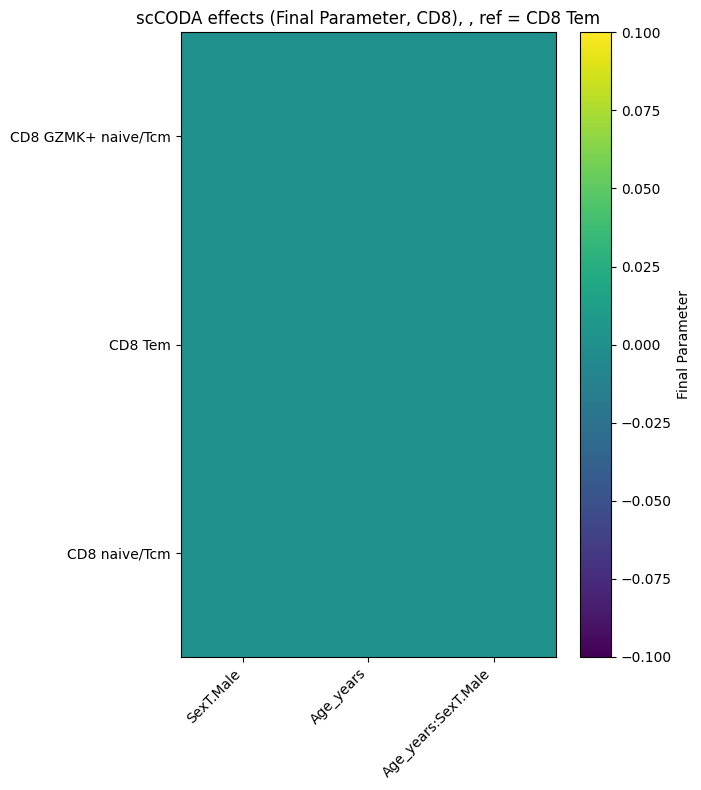

In [30]:
# inclusion pronbability heatmap
tmp_tem = effects_cd8_tem_plot.reset_index()
ip_tem = tmp_tem.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_tem = effects_cd8_tem_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_tem.values, aspect="auto")
plt.yticks(range(beta_tem.shape[0]), beta_tem.index)
plt.xticks(range(beta_tem.shape[1]), beta_tem.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD8), , ref = CD8 Tem")
plt.tight_layout()
plt.show()

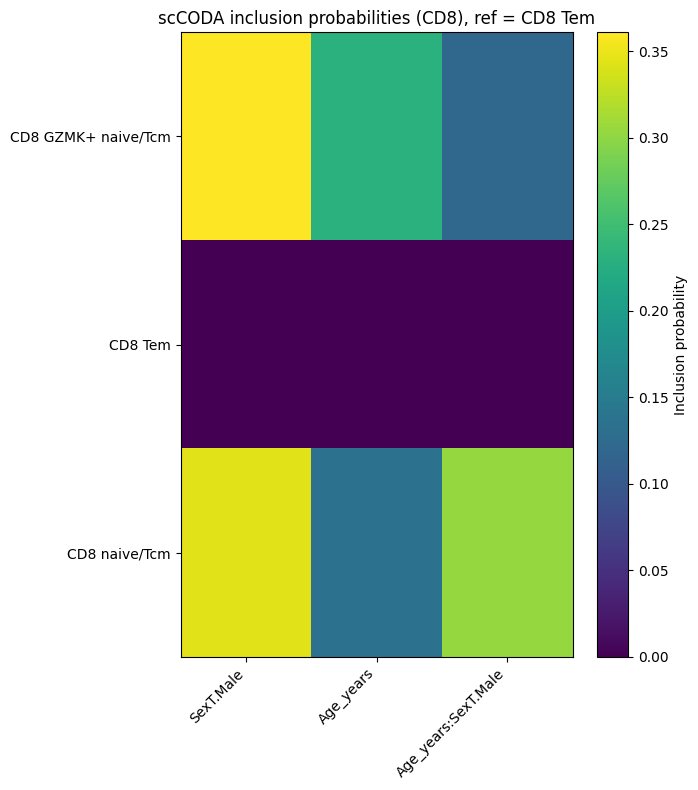

In [31]:
ip_tem = effects_cd8_tem_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_tem.values, aspect="auto")
plt.yticks(range(ip_tem.shape[0]), ip_tem.index)
plt.xticks(range(ip_tem.shape[1]), ip_tem.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD8), ref = CD8 Tem")
plt.tight_layout()
plt.show()